In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/vitthalbulbule/titaniccc/titanic.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv('/kaggle/input/datasets/vitthalbulbule/titaniccc/titanic.csv')

In [5]:
df.head()

,Cabin,Ticket,number,Survived
0,NaN,A/5 21171,5,0
1,C85,PC 17599,3,1
2,NaN,STON/O2. 3101282,6,1
3,C123,113803,3,1
4,NaN,373450,A,0


In [6]:
df['number'].unique()

array(['5', '3', '6', 'A', '2', '1', '4'], dtype=object)

<Axes: xlabel='number'>

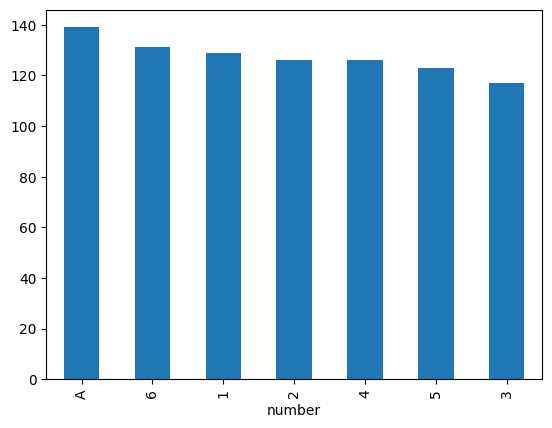

In [8]:
df['number'].value_counts().plot(kind='bar')

In [10]:
#Extracting Numerical Part
df['number_nun']=pd.to_numeric(df['number'],errors='coerce')

In [11]:
#Extracting Categorical Part
df['cat_part']=np.where(df['number_nun'].isnull(),df['number'],np.nan)

In [12]:
df.head()

,Cabin,Ticket,number,Survived,number_nun,cat_part
0,NaN,A/5 21171,5,0,5.0,NaN
1,C85,PC 17599,3,1,3.0,NaN
2,NaN,STON/O2. 3101282,6,1,6.0,NaN
3,C123,113803,3,1,3.0,NaN
4,NaN,373450,A,0,NaN,A


In [13]:
# Cabin

df['cabin_num']=df['Cabin'].str.extract('(\d+)')

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_57/4251472550.py:3: SyntaxWarning: invalid escape sequence '\d'
  df['cabin_num']=df['Cabin'].str.extract('(\d+)')


In [14]:
df['cabin_cat']=df['Cabin'].str[0]

In [15]:
df.head()

,Cabin,Ticket,number,Survived,number_nun,cat_part,cabin_num,cabin_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN
1,C85,PC 17599,3,1,3.0,NaN,85,C
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN
3,C123,113803,3,1,3.0,NaN,123,C
4,NaN,373450,A,0,NaN,A,NaN,NaN


In [16]:
# Ticket

df['ticket_num']=df['Ticket'].apply(lambda x:x.split()[-1])
df['ticket_num']=pd.to_numeric(df['ticket_num'],errors='coerce')

In [17]:
df['ticket_cat']=df['Ticket'].apply(lambda x:x.split()[0])
df['ticket_cat']=np.where(df['ticket_cat'].str.isdigit(),np.nan,df['ticket_cat'])

In [18]:
df.head()

,Cabin,Ticket,number,Survived,number_nun,cat_part,cabin_num,cabin_cat,ticket_num,ticket_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN,21171.0,A/5
1,C85,PC 17599,3,1,3.0,NaN,85,C,17599.0,PC
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN,3101282.0,STON/O2.
3,C123,113803,3,1,3.0,NaN,123,C,113803.0,NaN
4,NaN,373450,A,0,NaN,A,NaN,NaN,373450.0,NaN
